In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
random_state = 270
np.random.seed(random_state)

In [7]:
df = pd.read_csv('USA_housing_toy.csv')
df.head()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
0,79545.45857,5.682861,7.009188,4.09,23086.80050,1.059034e+06,"208 Michael Ferry Apt. 674\nLaurabury, NE 3701..."
1,79248.64245,6.002900,6.730821,3.09,40173.07217,1.505891e+06,"188 Johnson Views Suite 079\nLake Kathleen, CA..."
2,61287.06718,5.865890,8.512727,5.13,36882.15940,1.058988e+06,"9127 Elizabeth Stravenue\nDanieltown, WI 06482..."
3,63345.24005,7.188236,5.586729,3.26,34310.24283,1.260617e+06,USS Barnett\nFPO AP 44820
4,59982.19723,5.040555,7.839388,4.23,26354.10947,6.309435e+05,USNS Raymond\nFPO AE 09386


In [9]:
df.isnull().sum()

Avg. Area Income                0
Avg. Area House Age             0
Avg. Area Number of Rooms       0
Avg. Area Number of Bedrooms    0
Area Population                 0
Price                           0
Address                         0
dtype: int64

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 7 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Avg. Area Income              2500 non-null   float64
 1   Avg. Area House Age           2500 non-null   float64
 2   Avg. Area Number of Rooms     2500 non-null   float64
 3   Avg. Area Number of Bedrooms  2500 non-null   float64
 4   Area Population               2500 non-null   float64
 5   Price                         2500 non-null   float64
 6   Address                       2500 non-null   object 
dtypes: float64(6), object(1)
memory usage: 136.8+ KB


In [11]:
df.describe()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price
count,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2.500000e+03
mean,68593.117818,5.980941,7.005079,3.989816,36032.881352,1.233117e+06
std,10696.969146,1.007664,1.002411,1.241848,9803.908974,3.547254e+05
min,17796.631190,2.644304,3.236194,2.000000,172.610686,3.114052e+04
25%,61461.357480,5.328918,6.311252,3.150000,29381.948903,9.937032e+05
50%,68709.189825,5.981525,7.024682,4.050000,36073.859200,1.235056e+06
75%,75868.888025,6.680616,7.687694,4.500000,42683.564510,1.467923e+06
max,107701.748400,8.991399,10.759588,6.500000,69592.040240,2.469066e+06


In [16]:
x = df[['Avg. Area Income','Avg. Area House Age','Avg. Area Number of Rooms','Avg. Area Number of Bedrooms','Area Population']]
y = df['Price']

In [17]:
from sklearn.model_selection import train_test_split
x_train, x_test,y_train,y_test = train_test_split(x,y,test_size=0.4,random_state=random_state)

In [18]:
print(f"x_train:{x_train.shape}")
print(f"x_test:{x_test.shape}")
print(f"y_train:{y_train.shape}")
print(f"y_test:{y_test.shape}")

x_train:(1500, 5)
x_test:(1000, 5)
y_train:(1500,)
y_test:(1000,)


In [20]:
x_train[0:5]

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population
1278,61478.63393,4.269446,6.231330,4.26,36837.81793
1866,68450.26242,5.474151,7.376390,4.08,36474.39183
663,55554.79675,5.849591,7.753370,5.03,44903.44532
1147,69577.13762,6.019581,8.103830,5.05,48122.10195
917,63759.05070,6.135727,7.614218,6.23,35071.99599


In [21]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)


In [22]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [23]:
print("intercept:",model.intercept_)

intercept: 1234067.4108197466


In [24]:
coeff_df = pd.DataFrame(model.coef_,x.columns,columns=['coefficient'])
coeff_df

,coefficient
Avg. Area Income,229717.993146
Avg. Area House Age,164946.113552
Avg. Area Number of Rooms,118669.430772
Avg. Area Number of Bedrooms,-476.024353
Area Population,149292.872165


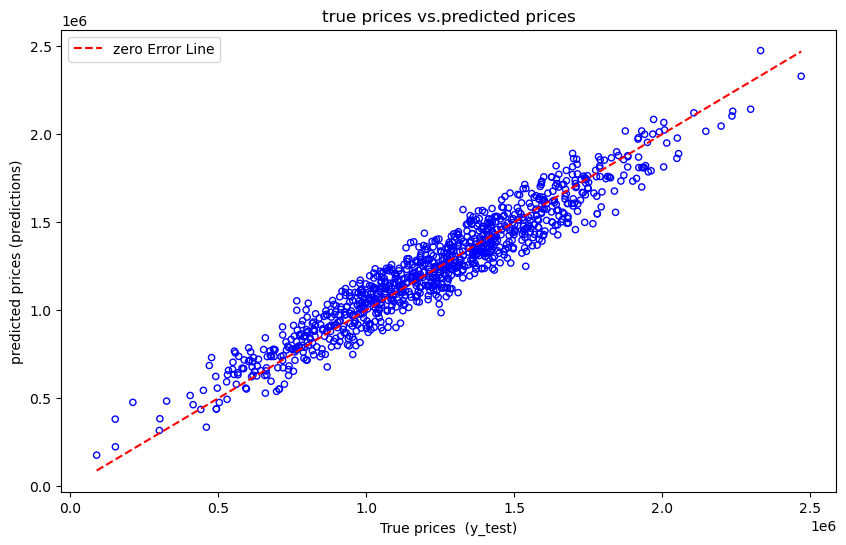

In [25]:
predictions = model.predict(x_test)
plt.figure(figsize=(10,6))
plt.scatter(y_test,predictions,s=20,facecolors='none',edgecolor='blue')
plt.xlabel("True prices  (y_test)")
plt.ylabel("predicted prices (predictions)")
plt.title("true prices vs.predicted prices")
plt.plot([y_test.min(),y_test.max()],[y_test.min(),y_test.max()],'r--',label='zero Error Line')
plt.legend()
plt.show()

In [ ]:
from sklearn import metrics
print('MAE      :',metrics.mean_abso